In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(".."))
from core_ntsa.generators import simulate_lorenz
from core_ntsa.noise_tools import add_white_noise, add_colored_noise
from core_ntsa.metrics import calculate_correlation_dimension


lorenz_data = simulate_lorenz(t_span=50.0, dt=0.01)
clean_x = lorenz_data[0]

x_white_noise = add_white_noise(clean_x, snr_db=1.0)
x_clored_noise = add_colored_noise(clean_x, color='pink', snr_db=10.0)


c:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\core_ntsa\metrics.py:355: SyntaxWarning: invalid escape sequence '\D'
  plt.title("Thuật toán Rosenstein: Hàm phân kỳ $y(i)$ theo $\Delta t$")
c:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\core_ntsa\metrics.py:356: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("Thời gian tiến hóa $\Delta t$ (số bước)")
c:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\core_ntsa\metrics.py:425: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("Thời gian tiến hóa $\Delta t$ (số bước)")


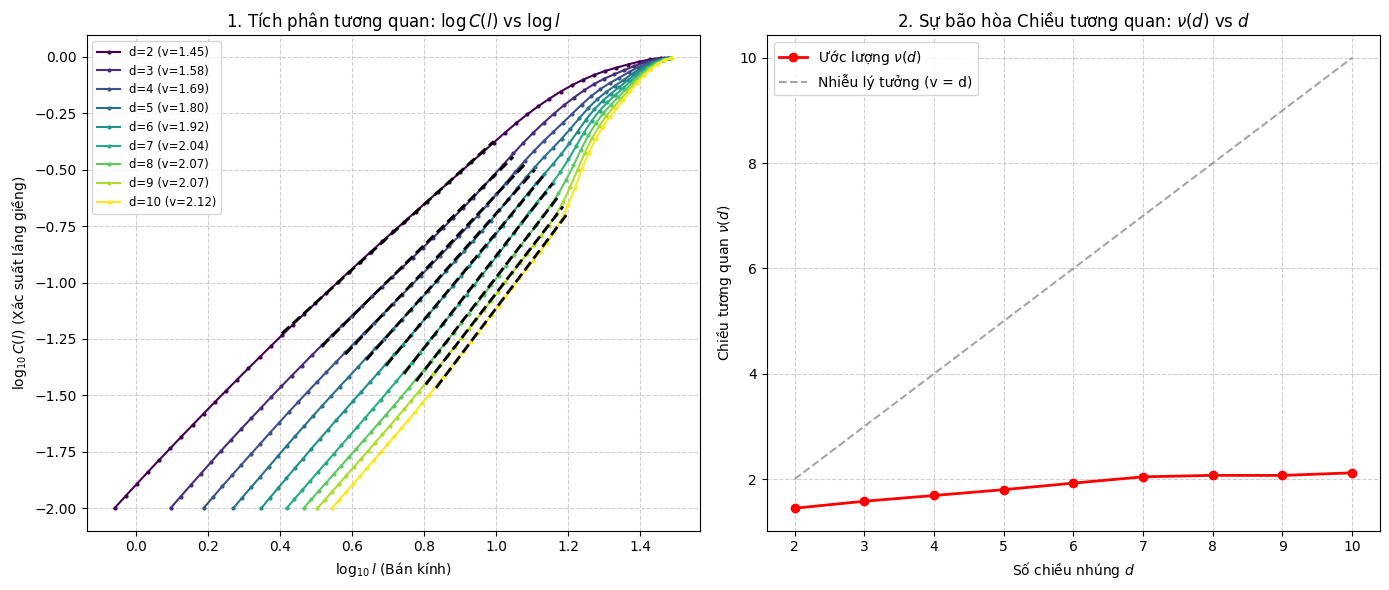

[np.float64(1.446464298826221),
 np.float64(1.5785984304837861),
 np.float64(1.6880216220036106),
 np.float64(1.7987698360342208),
 np.float64(1.9230492902404321),
 np.float64(2.0423405328385353),
 np.float64(2.070418886097521),
 np.float64(2.06886628078041),
 np.float64(2.118417378635412)]

In [2]:
calculate_correlation_dimension(clean_x, tau=16, min_d=2, max_d=10)

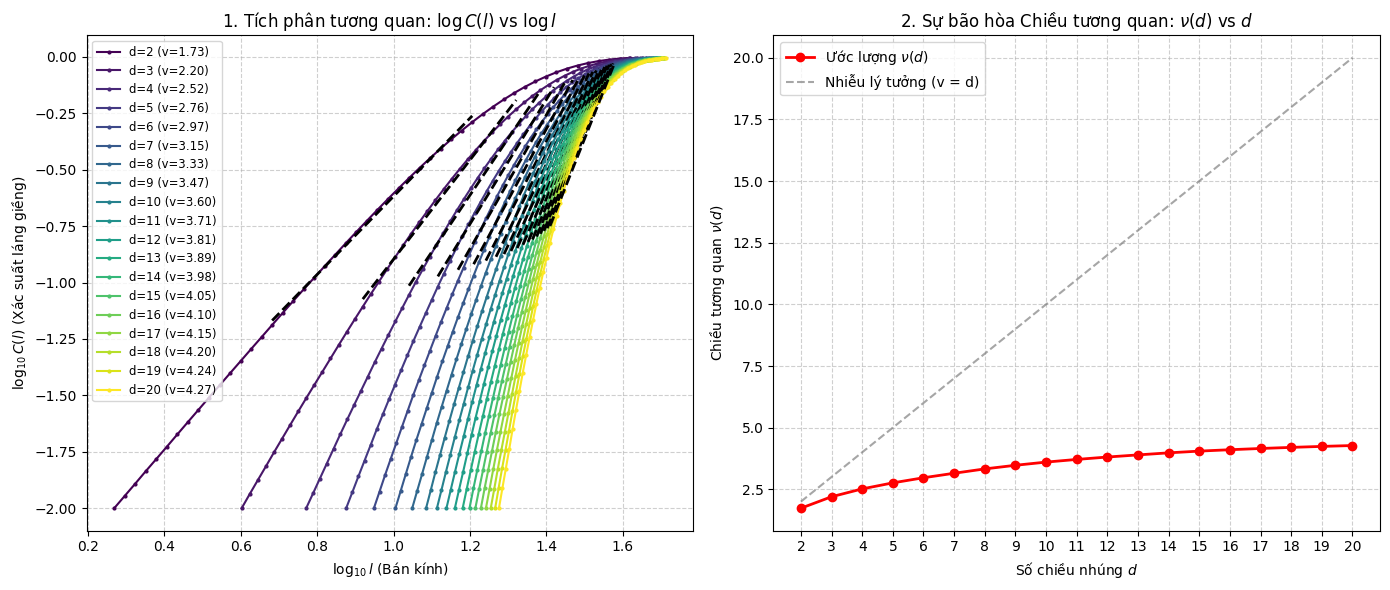

[np.float64(1.7321702474995222),
 np.float64(2.1972763642107096),
 np.float64(2.5157398336526726),
 np.float64(2.760276139301341),
 np.float64(2.9673453315676497),
 np.float64(3.1500502457292936),
 np.float64(3.3260881956343744),
 np.float64(3.473188896016402),
 np.float64(3.6022151117757994),
 np.float64(3.710451264298281),
 np.float64(3.807839222838261),
 np.float64(3.8941328448976855),
 np.float64(3.977676039170164),
 np.float64(4.047955986143014),
 np.float64(4.10434278165715),
 np.float64(4.154513305642954),
 np.float64(4.199054268542253),
 np.float64(4.239033519268449),
 np.float64(4.2744534201025015)]

In [15]:
calculate_correlation_dimension(x_white_noise, tau=16, min_d=2, max_d=20)

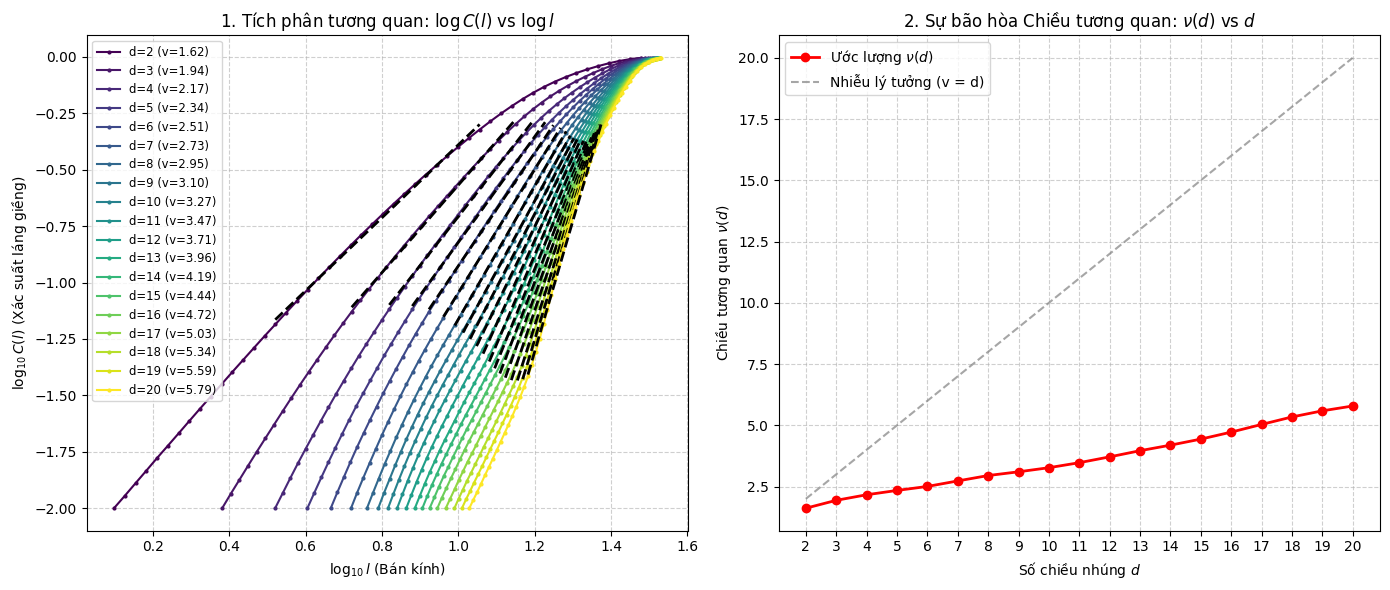

[np.float64(1.6165012889649826),
 np.float64(1.9381957933253977),
 np.float64(2.165386572028842),
 np.float64(2.3417970933327945),
 np.float64(2.5051478542716),
 np.float64(2.7298568727737424),
 np.float64(2.949825018263365),
 np.float64(3.102458027788767),
 np.float64(3.2697952986725554),
 np.float64(3.4743699436207995),
 np.float64(3.712026765425516),
 np.float64(3.963990425606607),
 np.float64(4.189638025755838),
 np.float64(4.43671696718051),
 np.float64(4.722058188315698),
 np.float64(5.034968930361681),
 np.float64(5.340961607442423),
 np.float64(5.5909627777322655),
 np.float64(5.7885099720461355)]

In [14]:
calculate_correlation_dimension(x_clored_noise, tau=16, min_d=2, max_d=20)

Đang sinh Nhiễu Hồng (alpha=1.0)...


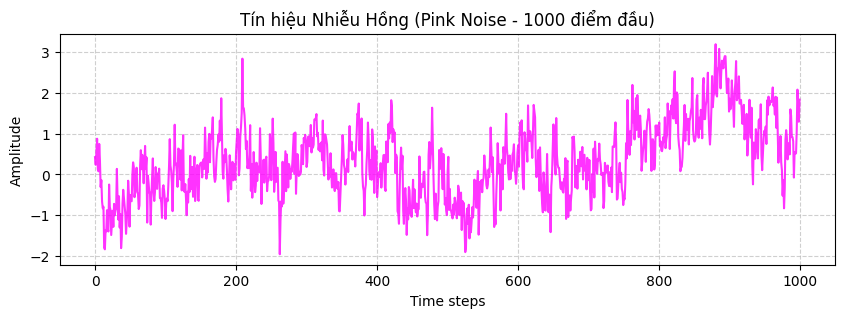

Đang tính Chiều tương quan (d chạy từ 2 đến 8)...
Cấu hình: tau = 10, w = 50


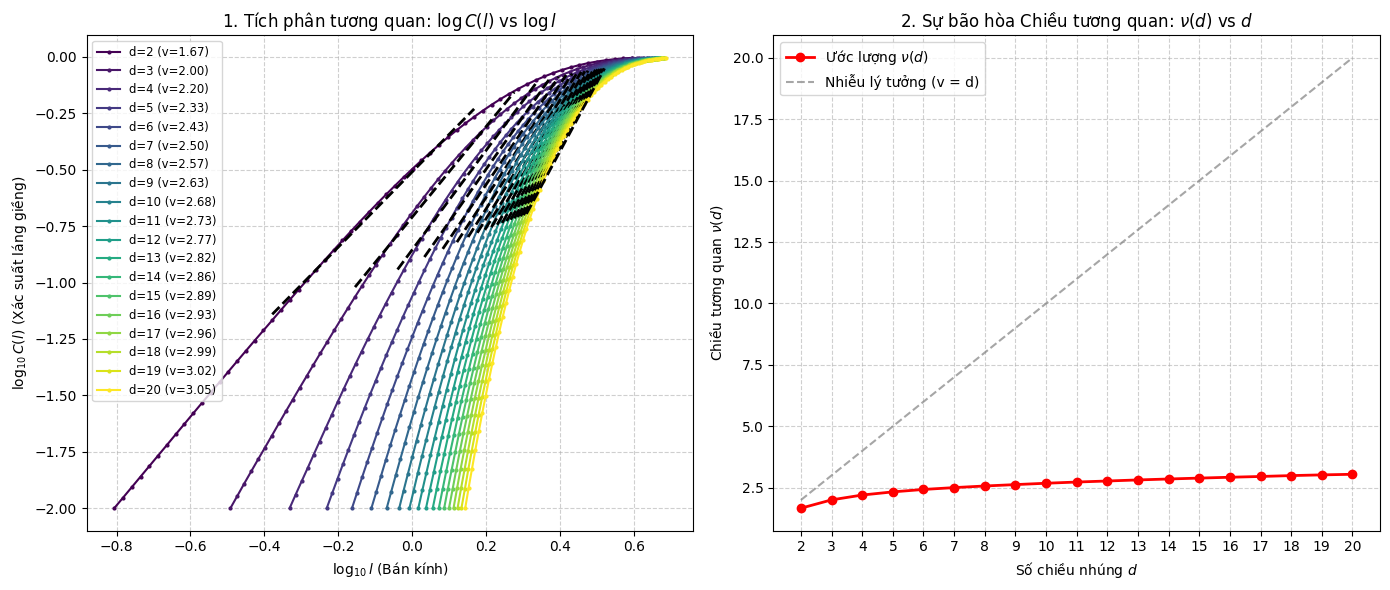


Kết quả Ước lượng v(d) theo từng chiều nhúng:
Chiều nhúng d=2: v = 1.666
Chiều nhúng d=3: v = 2.005
Chiều nhúng d=4: v = 2.202
Chiều nhúng d=5: v = 2.330
Chiều nhúng d=6: v = 2.429
Chiều nhúng d=7: v = 2.505
Chiều nhúng d=8: v = 2.570


In [13]:
def generate_colored_noise(N, alpha=1.0):
    """
    Sinh nhiễu màu bằng cách định hình phổ (Spectral Shaping) qua biến đổi Fourier.
    
    Parameters:
    -----------
    N     : int, số lượng điểm dữ liệu.
    alpha : float, hệ số suy giảm của phổ năng lượng (Power Law).
            alpha = 0.0: Nhiễu trắng (White Noise - Phổ phẳng)
            alpha = 1.0: Nhiễu hồng (Pink Noise - Rất phổ biến trong tín hiệu y sinh)
            alpha = 2.0: Nhiễu nâu (Brown Noise / Random Walk)
    """
    # 1. Khởi tạo nhiễu trắng trong miền tần số
    X_white = np.fft.rfft(np.random.randn(N))
    
    # 2. Tạo trục tần số
    f = np.fft.rfftfreq(N)
    f[0] = 1e-10  # Tránh lỗi chia cho 0 tại thành phần DC
    
    # 3. Định hình biên độ (PSD tỷ lệ với 1/f^alpha -> Biên độ tỷ lệ với 1/f^(alpha/2))
    S_f = X_white / (f ** (alpha / 2.0))
    S_f[0] = 0  # Xóa thành phần trung bình (DC = 0)
    
    # 4. Biến đổi ngược về miền thời gian
    colored_noise = np.fft.irfft(S_f, n=N)
    
    # 5. Chuẩn hóa (Z-score normalization)
    colored_noise = (colored_noise - np.mean(colored_noise)) / np.std(colored_noise)
    
    return colored_noise

# ==========================================
# THIẾT LẬP VÀ CHẠY THỰC NGHIỆM
# ==========================================

# 1. Khởi tạo dữ liệu
np.random.seed(42)
N_points = 5000

# Tạo Nhiễu Hồng (Pink noise) - Loại nhiễu có đặc tính tự đồng dạng giống hệt PRV/HRV
print("Đang sinh Nhiễu Hồng (alpha=1.0)...")
pink_noise = generate_colored_noise(N_points, alpha=1.0)

# Trực quan hóa tín hiệu Nhiễu Hồng trước khi phân tích
plt.figure(figsize=(10, 3))
plt.plot(pink_noise[:1000], color='magenta', alpha=0.8)
plt.title("Tín hiệu Nhiễu Hồng (Pink Noise - 1000 điểm đầu)")
plt.xlabel("Time steps")
plt.ylabel("Amplitude")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Chạy Thuật toán GP
# Tại sao w phải lớn? Vì nhiễu hồng có "quán tính" thời gian rất dài.
# Nếu w quá nhỏ, thuật toán sẽ đếm nhầm các điểm lân cận trên trục thời gian.
tau_opt = 10
w_theiler = 50  # Bắt buộc phải đủ lớn (w > tau) để ngắt tương quan tuyến tính

print(f"Đang tính Chiều tương quan (d chạy từ 2 đến 8)...")
print(f"Cấu hình: tau = {tau_opt}, w = {w_theiler}")

dimensions_pink = calculate_correlation_dimension(
    signal=pink_noise, 
    tau=tau_opt, 
    min_d=2, 
    max_d=20, 
    w=w_theiler, 
    n_radii=60
)

print("\nKết quả Ước lượng v(d) theo từng chiều nhúng:")
for d, v in zip(range(2, 9), dimensions_pink):
    print(f"Chiều nhúng d={d}: v = {v:.3f}")

Đang sinh Nhiễu Trắng (White Noise)...


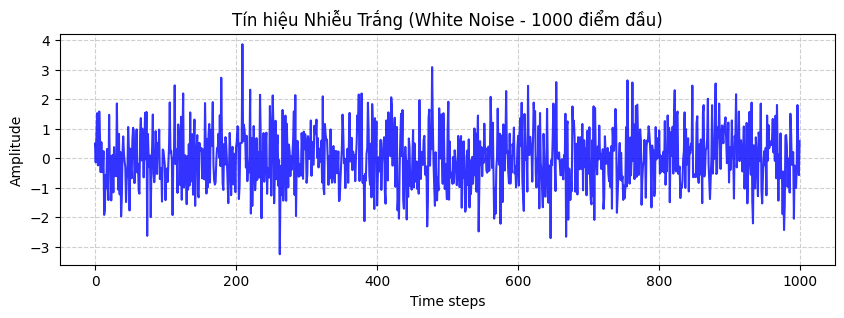

Đang tính Chiều tương quan (d chạy từ 2 đến 8)...
Cấu hình: tau = 1, w = 1


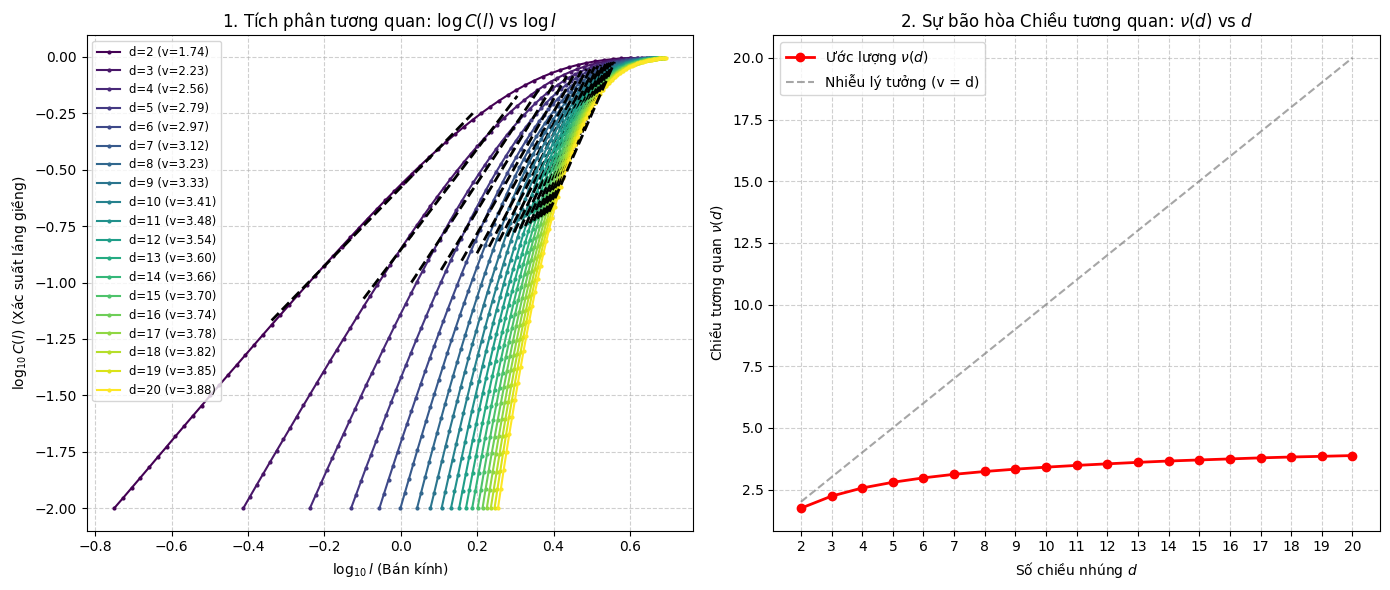


Kết quả Ước lượng v(d) theo từng chiều nhúng:
Chiều nhúng d=2: v = 1.742
Chiều nhúng d=3: v = 2.232
Chiều nhúng d=4: v = 2.562
Chiều nhúng d=5: v = 2.793
Chiều nhúng d=6: v = 2.973
Chiều nhúng d=7: v = 3.116
Chiều nhúng d=8: v = 3.231


In [12]:
def generate_white_noise(N):
    """
    Sinh nhiễu trắng chuẩn hóa (White Noise).

    Parameters:
    -----------
    N : int, số lượng điểm dữ liệu.
    """
    white_noise = np.random.randn(N)

    # Chuẩn hóa (Z-score normalization)
    white_noise = (white_noise - np.mean(white_noise)) / np.std(white_noise)

    return white_noise


# ==========================================
# THIẾT LẬP VÀ CHẠY THỰC NGHIỆM
# ==========================================

# 1. Khởi tạo dữ liệu
np.random.seed(42)
N_points = 5000

# Tạo Nhiễu Trắng (White Noise)
print("Đang sinh Nhiễu Trắng (White Noise)...")
white_noise = generate_white_noise(N_points)

# Trực quan hóa tín hiệu Nhiễu Trắng trước khi phân tích
plt.figure(figsize=(10, 3))
plt.plot(white_noise[:1000], color='blue', alpha=0.8)
plt.title("Tín hiệu Nhiễu Trắng (White Noise - 1000 điểm đầu)")
plt.xlabel("Time steps")
plt.ylabel("Amplitude")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Chạy Thuật toán GP
# Với nhiễu trắng không có tương quan dài hạn → không cần Theiler window lớn
tau_opt = 1
w_theiler = 1

print(f"Đang tính Chiều tương quan (d chạy từ 2 đến 8)...")
print(f"Cấu hình: tau = {tau_opt}, w = {w_theiler}")

dimensions_white = calculate_correlation_dimension(
    signal=white_noise,
    tau=tau_opt,
    min_d=2,
    max_d=20,
    w=w_theiler,
    n_radii=60
)

print("\nKết quả Ước lượng v(d) theo từng chiều nhúng:")
for d, v in zip(range(2, 9), dimensions_white):
    print(f"Chiều nhúng d={d}: v = {v:.3f}")

# BÁO CÁO THỰC NGHIỆM: ẢO ẢNH BÃO HÒA CỦA CHIỀU TƯƠNG QUAN ($D_2$) TRÊN TÍN HIỆU NHIỄU

## 1. Hiện tượng Quan sát (Empirical Observations)
* **Hệ Lorenz (Mẫu chuẩn):** $D_2$ bão hòa hoàn hảo tại $\nu \approx 2.05$, chứng minh tính tất định phi tuyến của hệ thống.
* **Nhiễu trắng (White Noise):** Kỳ vọng toán học là $\nu(d) = d$. Tuy nhiên, khi đạt đến các không gian chiều cao ($d \ge 8$), đường $\nu(d)$ bị gãy gập và sinh ra hiện tượng bão hòa giả tạo.
* **Nhiễu màu (Colored Noise):** Tín hiệu tự động bão hòa và hội tụ ở một số chiều hữu hạn, bắt chước hoàn hảo cấu trúc của một hệ hỗn loạn tất định (Chaos).

## 2. Giải phẫu Nguyên nhân (Core Mechanisms)
Sự sụp đổ của thuật toán Grassberger-Procaccia (G-P) trên dữ liệu thực nghiệm xuất phát từ 3 giới hạn cốt lõi:

* **Thiếu hụt thống kê & Lời nguyền chiều (Eckmann-Ruelle Limit):** Khi số chiều $d$ tăng, thể tích không gian pha bùng nổ theo hàm mũ. Với chuỗi dữ liệu thực nghiệm có độ dài hữu hạn (ví dụ $N=5000$), các vector trạng thái bị đẩy ra quá xa nhau. Các quả cầu khảo sát ở thang đo $l$ nhỏ bị trống rỗng, ép thuật toán phải đo lường ở thang đo vĩ mô (chạm vào ranh giới vật lý của hệ thống), sinh ra bão hòa giả. Giới hạn đo lường tối đa khả thi là:
    $$D_{max} \approx 2 \log_{10}(N)$$
* **Giới hạn độ phân giải cảm biến (Hiệu ứng $l_{min}$):** Mọi thiết bị đo lường đều có sai số lượng tử hóa, tạo ra một khoảng cách vật lý nhỏ nhất $l_{min}$. Khi không gian bị nhúng lên số chiều quá lớn, toàn bộ cấu trúc nhiễu ngẫu nhiên vi mô bị ép văng xuống dưới ngưỡng $l_{min}$. Thuật toán G-P hoàn toàn "mù" trước lớp nhiễu này và chỉ đo được các cấu trúc thô đại bên trên.
* **Nghịch lý Osborne-Provenzale (Trí nhớ dài hạn của Nhiễu màu):** Nhiễu màu (phổ biến trong tín hiệu y sinh) mang đặc tính tự tương quan rất mạnh. Quán tính thời gian này nối các điểm dữ liệu thành những "sợi chỉ" kéo dài. Thuật toán G-P đếm nhầm cấu trúc thời gian này thành sự cuộn gập hình học phân dạng trong không gian, trực tiếp tạo ra ảo ảnh hỗn loạn.

## 3. Kết luận Phương pháp luận (Methodological Conclusion)
* **Giới hạn của Thuật toán G-P:** Tuyệt đối không sử dụng sự bão hòa của $D_2$ làm bằng chứng độc lập để kết luận tính hỗn loạn trên các chuỗi tín hiệu y sinh ngắn (như các cửa sổ PPG 60 giây). 
* **Giải pháp Bắt buộc:** Để đập tan ảo ảnh do nhiễu và giới hạn dữ liệu gây ra, mọi phân tích NTSA phải được đặt vào một khung kiểm định thống kê khắt khe. Phải sử dụng **Thuật toán IAAFT** để sinh tập dữ liệu đối chứng (duy trì phổ nhiễu màu) và sử dụng **Sai số dự báo phi tuyến (Nonlinear Prediction Error)** làm trọng tài phân xử nhằm loại bỏ hoàn toàn các dương tính giả.